# **Modeling (Part 2): Logistic Regression and K-Nearest Neighbors**

In this notebook, we'll learn how to use **classification models** to predict categories.

We'll cover:

1. Classification
2. Logistic Regression
3. Evaluating classification models
4. K-Nearest Neighbors (KNN)
5. Comparing the two models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import accuracy_score, root_mean_squared_error, r2_score, ConfusionMatrixDisplay

## Classification

In supervised learning:

- **Regression** predicts a numerical value
- **Classification** predicts a category or class

For example:

- House price → Regression
- Spam vs. Not Spam → Classification
- Benign vs. Malignant Tumor → Classification

In this notebook, our target (`y`) contains **class labels** rather than continuous numerical values.

# Logistic Regression

Logistic Regression is used for **classification**.

Instead of predicting a continuous numerical value, it predicts which class an observation belongs to.

For example, we can use Logistic Regression to predict whether a tumor is:

- **Malignant**
- **Benign**

## Breast Cancer Wisconsin Dataset

We'll use the Breast Cancer Wisconsin dataset from `scikit-learn`.

Each row represents a tumor sample.

The dataset contains measurements describing characteristics of each tumor.

Our goal is to classify each tumor as **malignant** or **benign**.

In [2]:
cancer = load_breast_cancer(as_frame=True)

X = cancer.data
y = cancer.target

In [3]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
print("Number of observations:", len(X))
print("Number of features:", X.shape[1])
print("Classes:", cancer.target_names)

Number of observations: 569
Number of features: 30
Classes: ['malignant' 'benign']


For this dataset:

- `0` = malignant
- `1` = benign

`X` contains the information we give the model.

`y` contains the class we want the model to predict.

## Training and Testing Data

Just like with Linear Regression, we'll split the dataset into:

- **Training data:** used to train the model
- **Testing data:** used to evaluate the model

We'll use 80% for training and 20% for testing.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=107,
    stratify=y
)

`stratify=y` keeps approximately the same proportion of each class in the training and testing sets.

In [6]:
print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 455
Testing examples: 114


## Feature Scaling

The features in this dataset are measured on different numerical scales.

For example, one feature may contain small decimal values while another may contain values in the hundreds.

We will use `StandardScaler` to put the features on a more comparable scale.

This is especially important later when we use K-Nearest Neighbors because KNN relies on distances between observations.

In [7]:
# make scaler
scaler = StandardScaler()

# fit and transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# why don't we scale our y?

## Creating the Logistic Regression Model

First, we'll create a Logistic Regression model.

In [8]:
# initialize logistic regression model
log_model = LogisticRegression(max_iter=1000, random_state=107)

At this point, the model hasn't learned anything yet.

Calling `.fit()` trains the model using the training data.

In [9]:
# fit our model
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",107
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

## Making Predictions

Now that the model has been trained, we can use `.predict()` to predict the class of each observation in the test set.

In [13]:
y_pred_log = log_model.predict(X_test_scaled)
y_pred_log

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 0])

## Evaluating Logistic Regression

For classification, one simple metric is **accuracy**.

Accuracy measures the proportion of predictions that the model got correct.

In [14]:
# get accuracy
log_accuracy = accuracy_score(y_true=y_test, y_pred=y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.9736842105263158


### Confusion Matrix

Accuracy tells us how often the model was correct overall.

A confusion matrix shows which classes were predicted correctly and incorrectly.

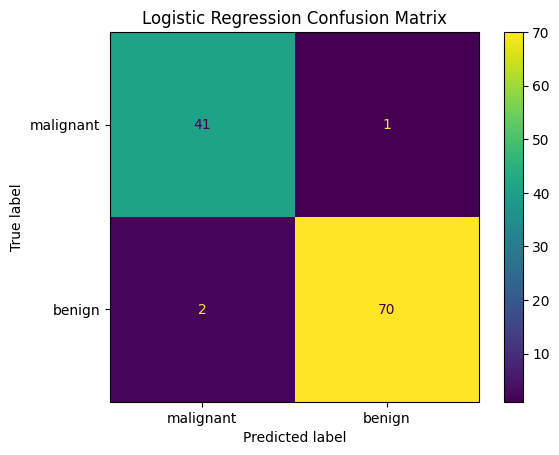

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=cancer.target_names
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

# K-Nearest Neighbors (KNN)

KNN can be used for both **classification** and **regression**.

The main idea is that predictions are based on observations that are closest to a new data point.

We'll first use KNN for classification.

## KNN Classification

Suppose we choose:

$$
k = 5
$$

For a new observation, KNN:

1. Finds the 5 closest observations in the training data
2. Looks at their class labels
3. Predicts the class that appears most often

### Why Scaling Matters

KNN uses distance to determine which observations are closest.

If one feature has much larger numerical values than another, it could dominate the distance calculation.

That's why scaling is especially important for KNN.

In [16]:
# initialize KNN classifier with k = 5
knn_model = KNeighborsClassifier(n_neighbors=5)

In [17]:
# fit model
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [18]:
# get predictions
y_pred_knn = knn_model.predict(X_test_scaled)

In [19]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9824561403508771


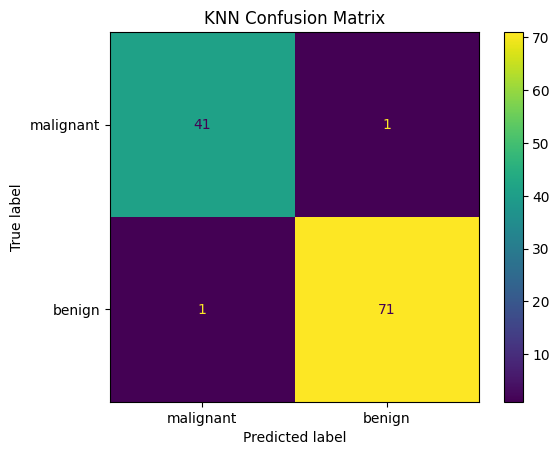

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=cancer.target_names
)

plt.title("KNN Confusion Matrix")
plt.show()

# Logistic Regression vs. KNN

Both models were trained and tested using the same data.

Let's compare their accuracy.

In [21]:
print("Logistic Regression")
print("Accuracy:", log_accuracy)

print("\nK-Nearest Neighbors")
print("Accuracy:", knn_accuracy)

Logistic Regression
Accuracy: 0.9736842105263158

K-Nearest Neighbors
Accuracy: 0.9824561403508771


The two models approach classification differently.

### Logistic Regression

- Learns relationships between the features and the target
- Uses a learned model to make predictions

### KNN

- Makes predictions based on nearby training observations
- Uses distance between observations
- Depends on the chosen value of $k$

# KNN Regression

KNN can also be used for **regression**, where the goal is to predict a numerical value.

For classification, nearby observations vote on a class.

For regression, KNN uses the target values of nearby observations to make a numerical prediction.

Let's return to the **California Housing dataset** from our Linear Regression notebook.

In [22]:
housing = pd.read_csv("california_housing.csv")

X = housing.drop(columns="MedHouseVal")
y = housing["MedHouseVal"]

## Predicting House Value with KNN

Just like in our Linear Regression notebook, we'll start with one feature:

**Median Income (`MedInc`)**

Our goal is to predict **Median House Value**.

In [23]:
X_single = X[["MedInc"]]
y_single = y

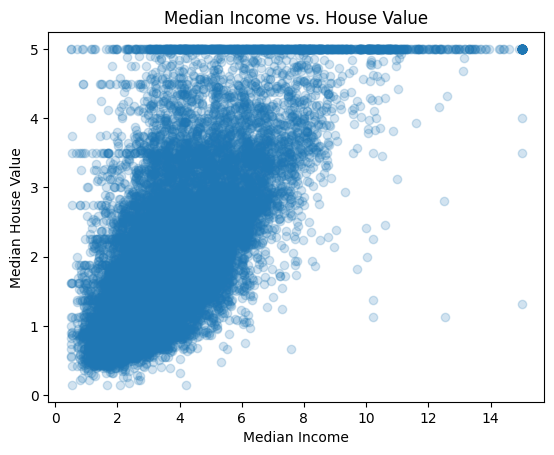

In [24]:
plt.scatter(X_single["MedInc"], y_single, alpha=0.2)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs. House Value")

plt.show()

We can see that median income and median house value are related.

Instead of fitting one straight line like Linear Regression, KNN Regression makes predictions based on nearby observations.

## Training and Testing Data

We'll split the data into training and testing sets, just like we did for Linear Regression.

In [26]:
X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
    X_single,
    y_single,
    test_size=0.2,
    random_state=42
)

## Creating the KNN Regression Model

We'll start with:

$$
k = 5
$$

For each new observation, KNN finds the 5 closest observations in the training data and uses their target values to make a prediction.

But first, we need to scale our data, just like in classification:

In [29]:
# make scaler
scaler = StandardScaler()

# fit and transform
X_train_single_scaled = scaler.fit_transform(X_train_single)
X_test_single_scaled = scaler.transform(X_test_single)

In [30]:
# initialize KNN regressor with k = 5
knn_reg = KNeighborsRegressor(n_neighbors=5)

In [31]:
# fit model
knn_reg.fit(X_train_single_scaled, y_train_single)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [33]:
# get predictions
y_pred_reg = knn_reg.predict(X_test_single_scaled)
y_pred_reg

array([1.3358  , 1.5776  , 1.578   , ..., 4.922608, 1.5152  , 1.942   ],
      shape=(4128,))

## Evaluating KNN Regression

We can evaluate KNN Regression using the same metrics we used for Linear Regression:

- **RMSE** measures prediction error
- **$R^2$** measures how much variation in the target is explained by the model

In [34]:
knn_rmse = root_mean_squared_error(y_true=y_test_single, y_pred=y_pred_reg)

knn_r2 = r2_score(y_true=y_test_single, y_pred=y_pred_reg)

print("RMSE:", knn_rmse)
print("R²:", knn_r2)

RMSE: 0.9122763910464862
R²: 0.36489429828387165


## Visualizing KNN Regression

Let's compare the actual observations with the predictions made by KNN.

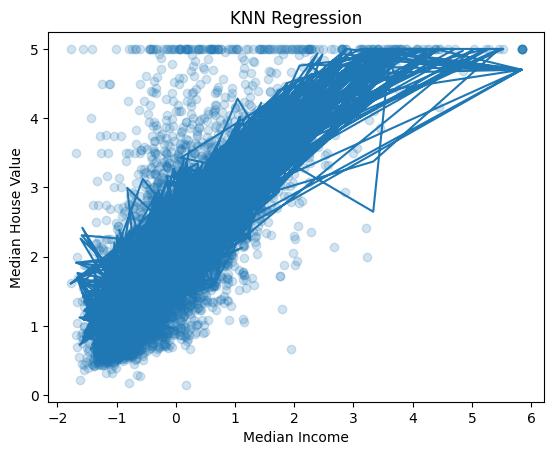

In [42]:
sorted_indices = np.argsort(y_test_single)

plt.scatter(
    X_test_single_scaled[:, 0],
    y_test_single,
    alpha=0.2
)

plt.plot(
    X_test_single_scaled[:, 0][sorted_indices],
    y_pred_reg[sorted_indices]
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("KNN Regression")

plt.show()

Unlike Linear Regression, KNN Regression does not fit one straight line through the entire dataset.

Its predictions depend on the values of nearby observations.

### KNN Classification vs. KNN Regression

The main idea behind KNN stays the same: look at nearby observations.

The difference is how those neighbors are used:

- **KNN Classification:** nearby observations vote on a class
- **KNN Regression:** nearby target values are used to predict a numerical value

## Try it yourself!

Try a fitting K-Nearest Neighbors regressor using all the predictors (similar to our multiple linear regression from last workshop). Try different values of $k$ to find which one is best! How does your best KNN regressor compare to our single-feature KNN model? What about our linear regression model from last workshop?

In [ ]:
# your code heeeeeeeere

...